In [1]:
from __future__ import annotations

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [3]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

In [4]:
import os
import datetime
import numpy as np
import sklearn.metrics
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set_theme(rc={'figure.figsize': (10, 10), 'axes.grid': False})

In [5]:
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.is_available())

CUDA: 12.8
GPU: True


In [6]:
rng = np.random.default_rng()

In [7]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [8]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(model.predict(inputs), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [9]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [10]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto')
y = np.array(list(map(int, y)))
X_train, X_test, y_train, y_test = train_test_split(X, y)

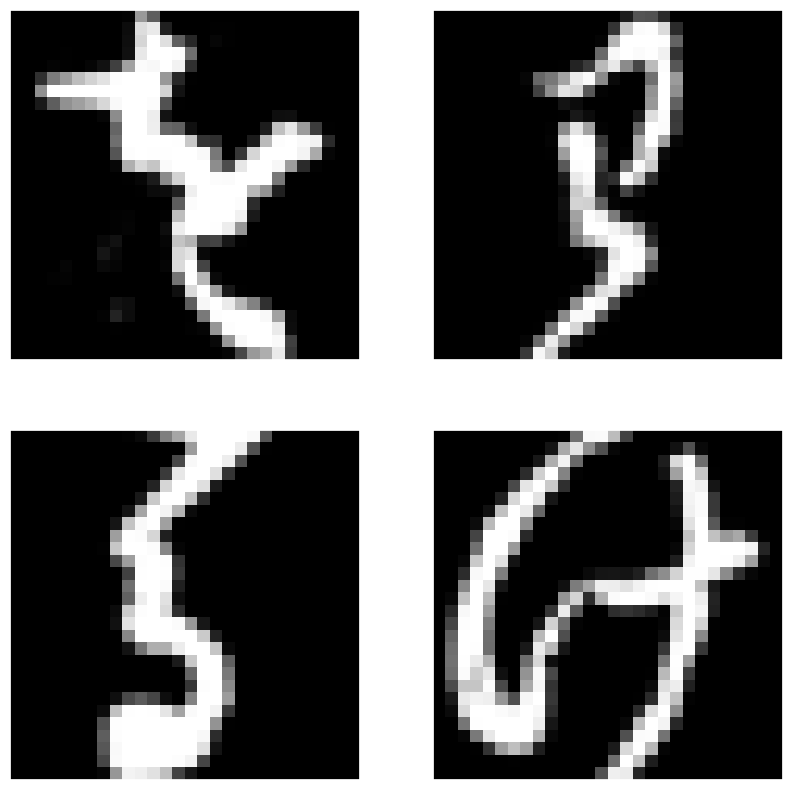

In [11]:
plot_grid(X_train)

In [12]:
counts = { j: np.sum(y_train == i) for i, j in enumerate(label_description) }

In [13]:
sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

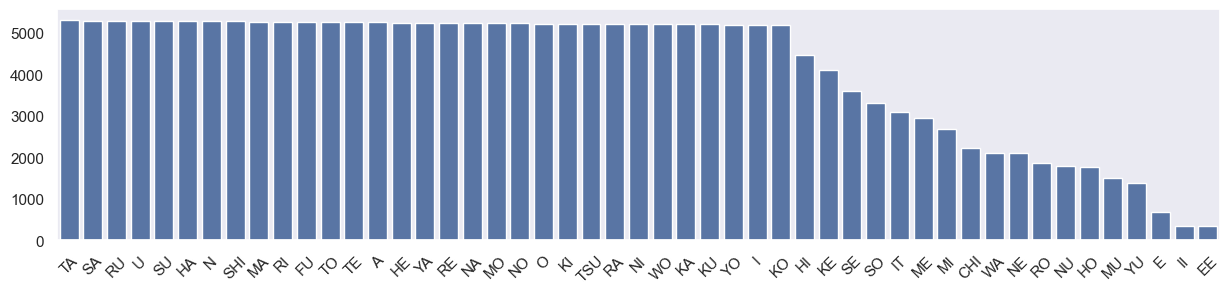

In [14]:
plt.figure(figsize=(15, 3))
sns.barplot(x=list(sorted_counts.keys()), y=list(sorted_counts.values()))
plt.xticks(rotation=45)
plt.show()

In [15]:
img_len = X_train[0].shape[0]
img_len, np.sqrt(img_len)

(784, np.float64(28.0))

## Flattened images
Use Dense layers

In [16]:
# create train and validation datasets, these datasets should use flattened images
X_train.shape

(203184, 784)

In [71]:
x = inputs = keras.layers.Input(shape=(784,))
x = keras.layers.Rescaling(1./255)(x)

x = keras.layers.Dense(512, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)

x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)

x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)

x = keras.layers.Dense(49, activation='softmax')(x)

In [72]:
model = keras.models.Model(inputs=inputs, outputs=x)

In [73]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 576,049 (2.20 MB)

 Trainable params: 574,257 (2.19 MB)

 Non-trainable params: 1,792 (7.00 KB)

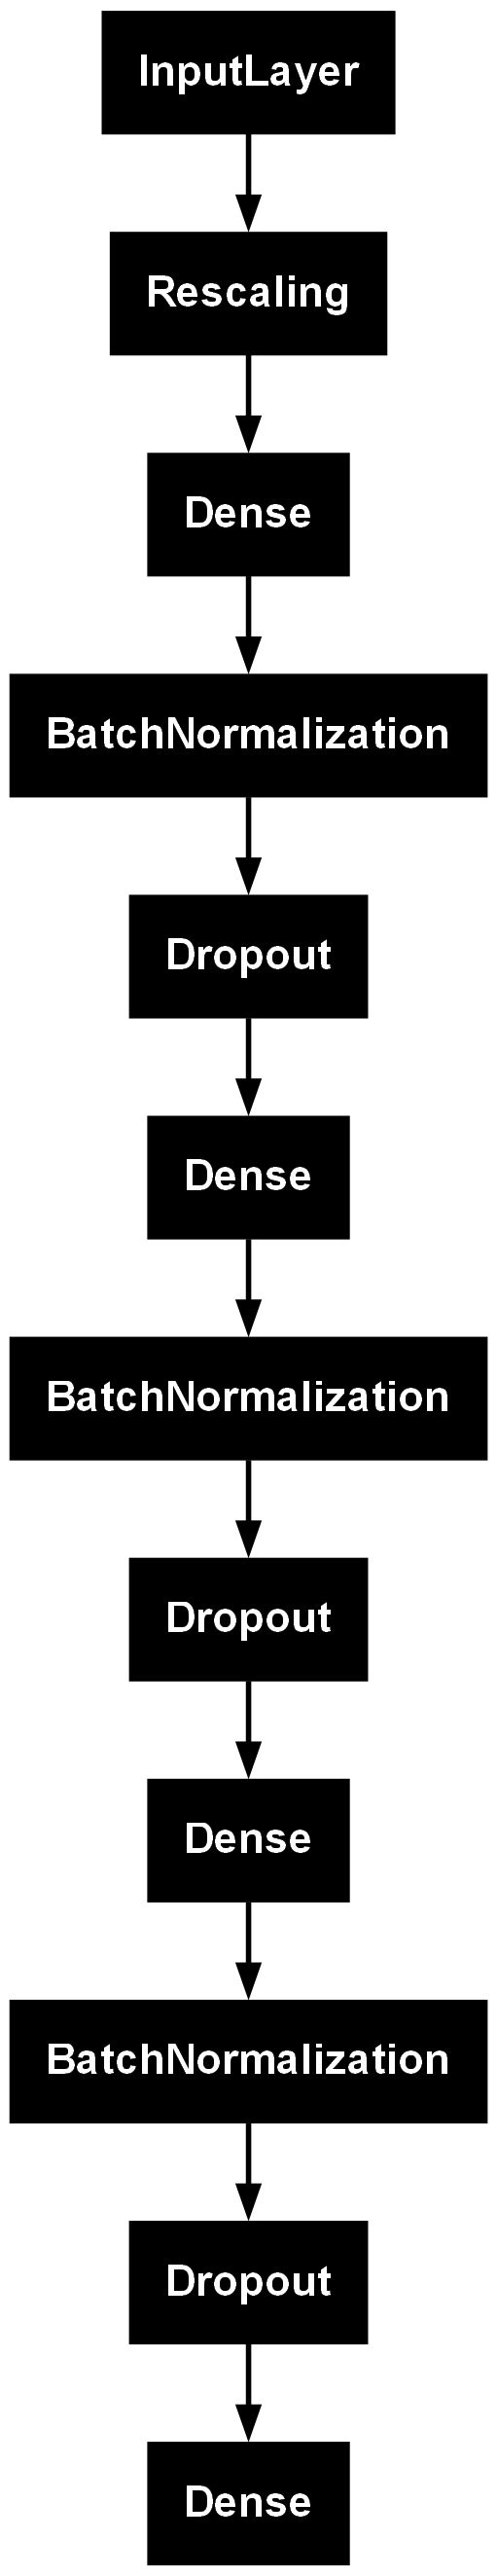

In [74]:
keras.utils.plot_model(model)

In [75]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

In [76]:
model_dir = os.path.join(logdir, "model.keras")

In [77]:
callbacks = [
    keras.callbacks.ModelCheckpoint(model_dir, save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [78]:
# compile the model, make sure to add accuracy metric
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
# train the model, make sure to use callbacks and validation dataset
model.fit(X_train, y_train, batch_size=512, epochs=10, validation_split=0.2, callbacks=callbacks)

Epoch 1/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.6029 - loss: 1.5600 - val_accuracy: 0.7794 - val_loss: 0.8456
Epoch 2/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7500 - loss: 0.9278 - val_accuracy: 0.8374 - val_loss: 0.5852
Epoch 3/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.7896 - loss: 0.7684 - val_accuracy: 0.8573 - val_loss: 0.5101
Epoch 4/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8113 - loss: 0.6823 - val_accuracy: 0.8708 - val_loss: 0.4611
Epoch 5/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8263 - loss: 0.6225 - val_accuracy: 0.8801 - val_loss: 0.4254
Epoch 6/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8368 - loss: 0.5813 - val_accuracy: 0.8878 - val_loss: 0.3996
Epoch 7/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.8450 - loss: 0.5494 - val_accuracy: 0.8910 - val_loss: 0.3902
Epoch 8/10
318/318 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8521 - loss: 0.5228 - 

In [80]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


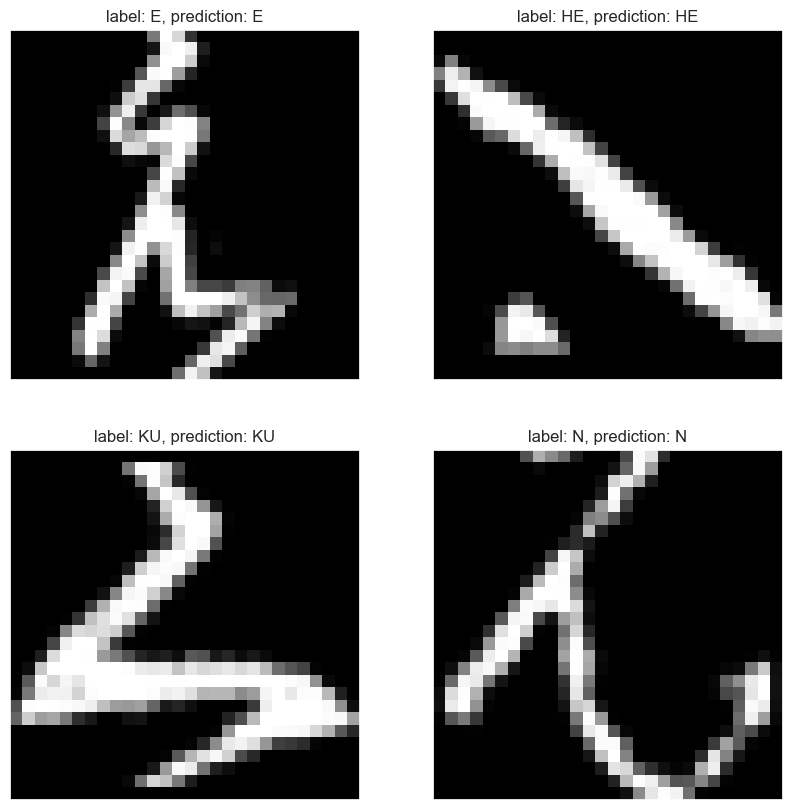

In [81]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [87]:
y_pred_probs = model.predict(X_test, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)

  1/133 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


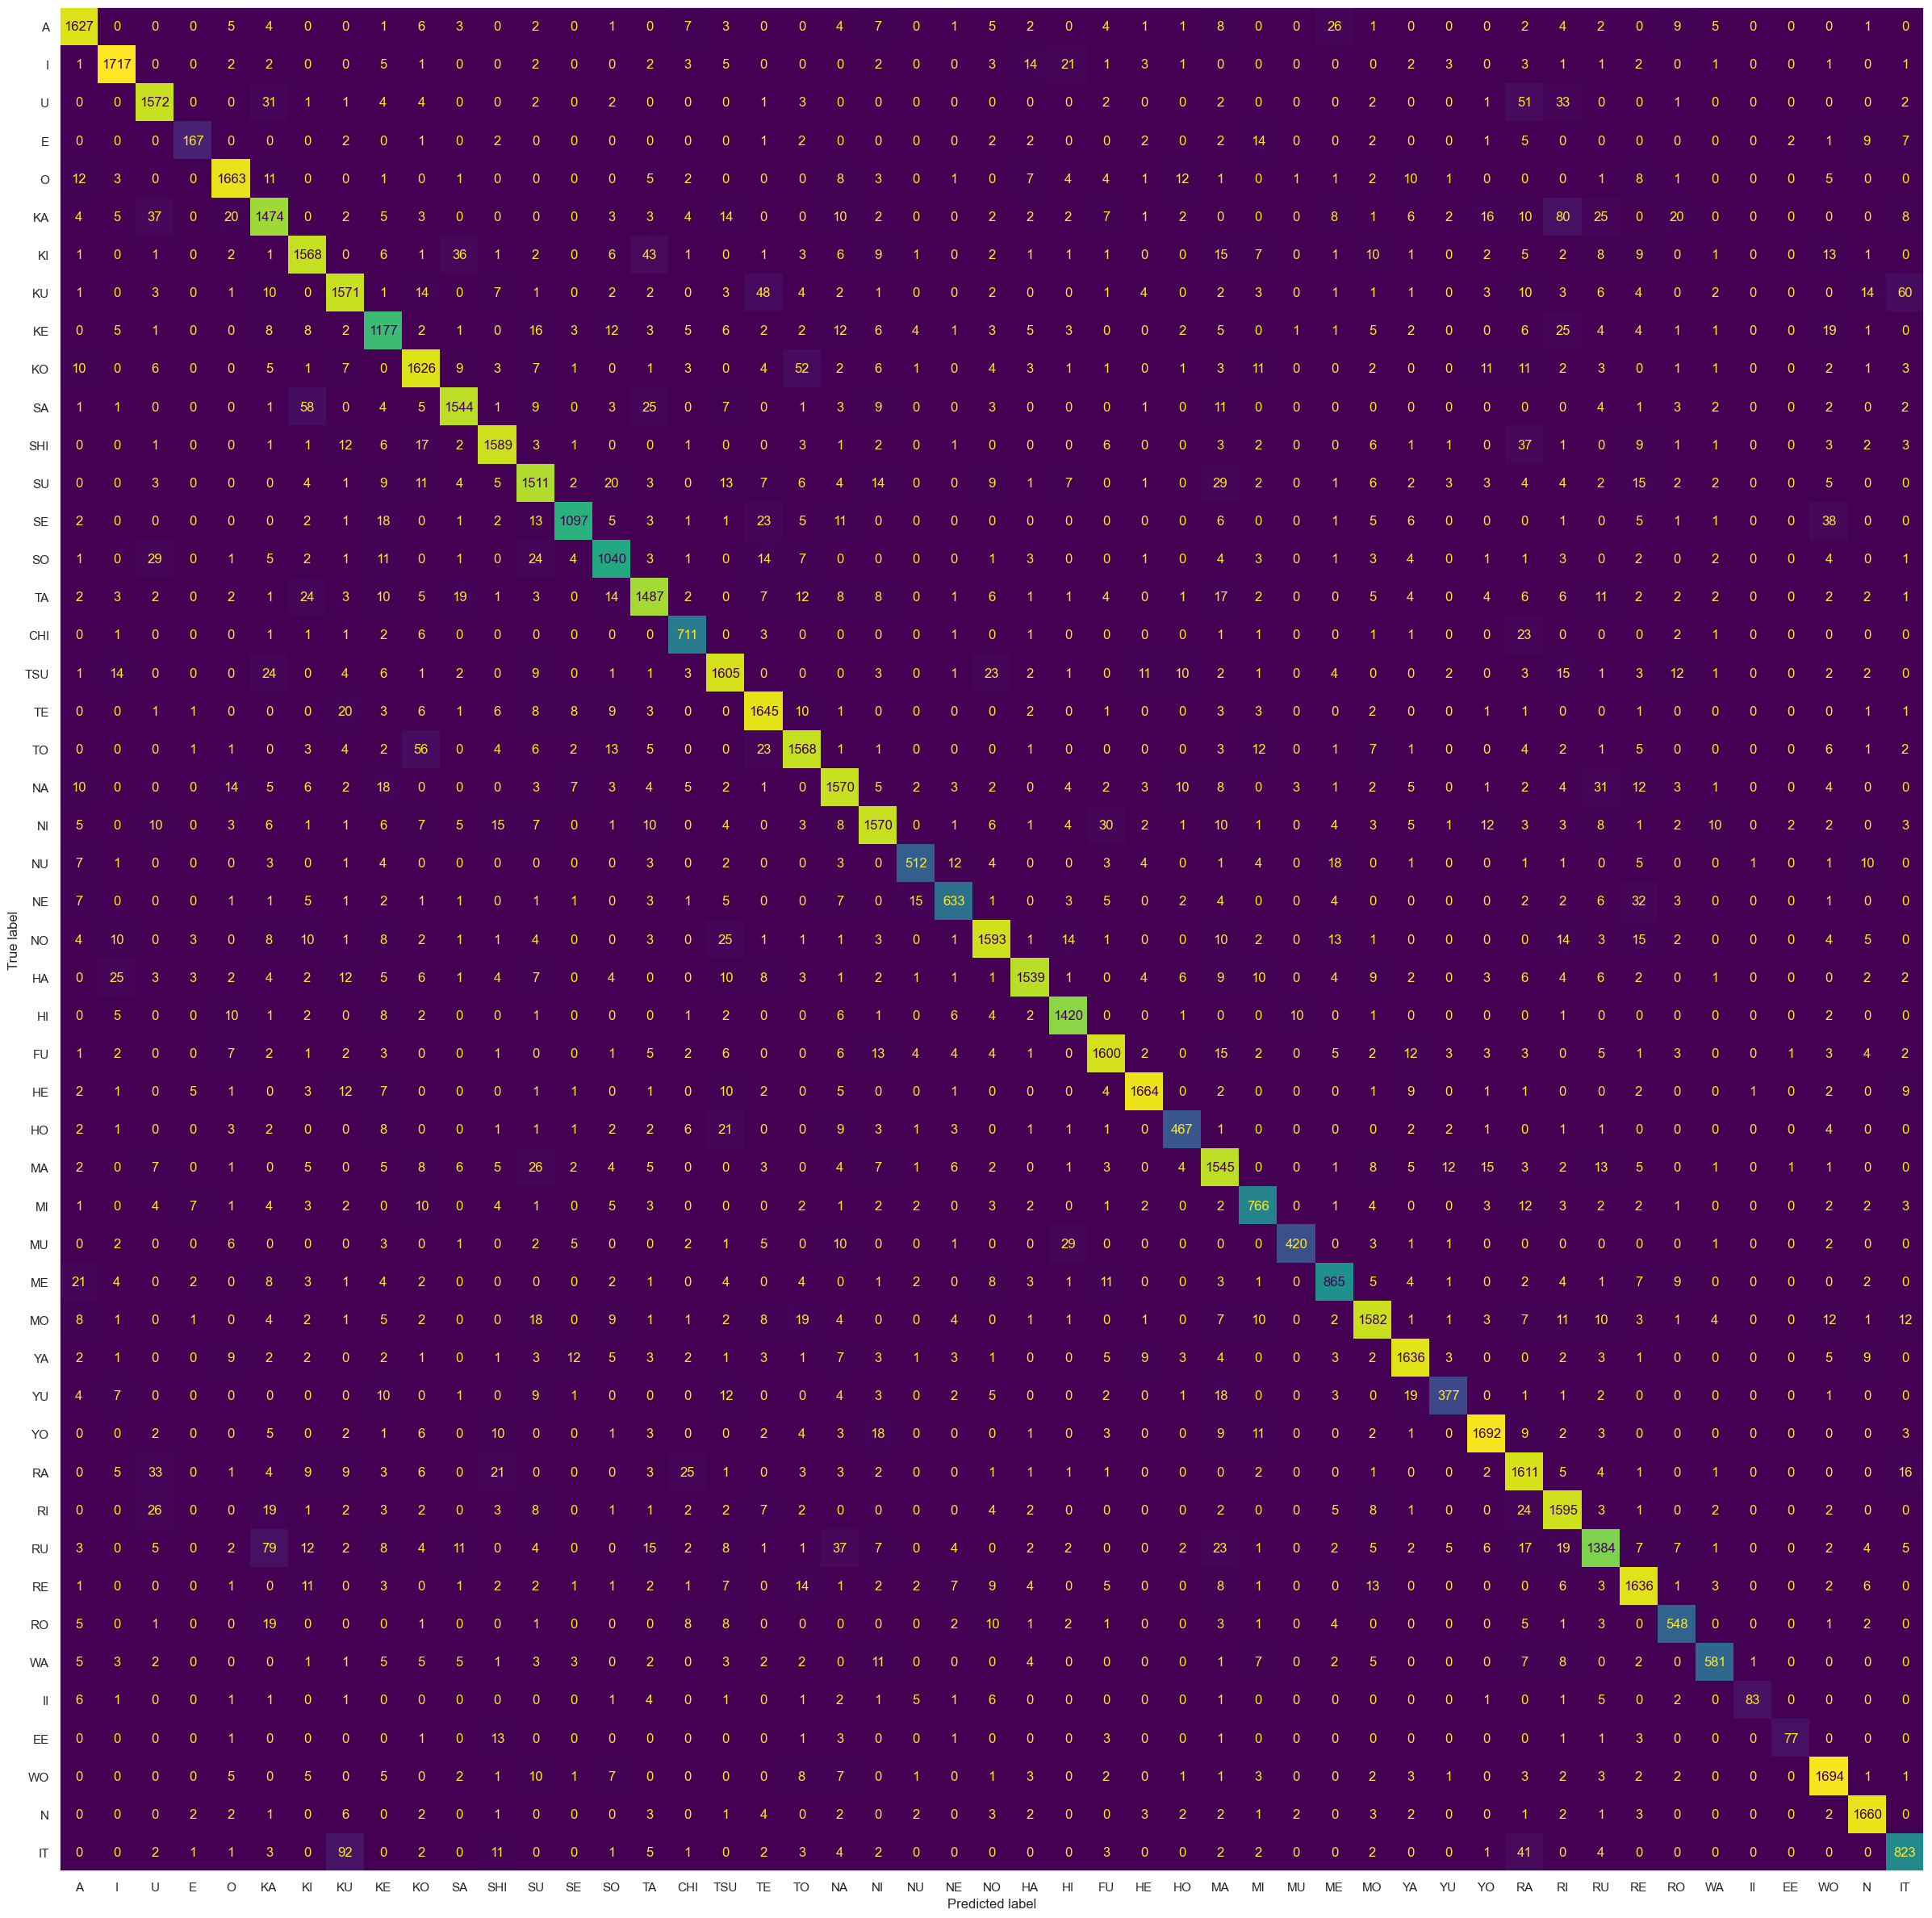

In [89]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [90]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.8849752666313511)

## Actual images
Use Conv2D layers with Dense layer on top

In [ ]:
# create train and validation datasets, these datasets should use 28x28x1 images

In [ ]:
# create model, this model should accept a 28x28x1 image

In [ ]:
model.summary()

In [ ]:
keras.utils.plot_model(model)

In [ ]:
logdir = os.path.join('logs/kuzushiji-49/', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(logdir, save_best_only=True, monitor='val_loss'),
    keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [ ]:
# compile the model, make sure to add accuracy metric

In [ ]:
# train the model, make sure to use callbacks and validation dataset

In [ ]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

In [ ]:
plot_grid_and_label(images, y_test, model, label_description=label_description, flatten_image=False)

In [ ]:
y_pred = ... # make predictions

In [ ]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [ ]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])